# Jump diffusion

A jump-diffusion process is a smooth diffusion (like GBM) punctuated by sudden *jumps* — the model for prices that mostly drift but occasionally gap on news. It is a realistic test for methods that must distinguish ordinary volatility from discrete shocks.

::: {.callout-note}
## The model

$$dS_t = \mu S_t\, dt + \sigma S_t\, dW_t + S_{t^-}\, dJ_t, \qquad N_t \sim \mathrm{Poisson}(\lambda\, dt)$$

A continuous diffusion accumulates small changes while a Poisson jump process adds occasional discrete moves. The jump intensity sets how often jumps occur; the jump-size distribution sets how large they are. Between jumps the series behaves like its underlying diffusion.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import JumpDiffusionGenerator

## 1. Basic jump diffusion model

A standard model with moderate jump frequency and symmetric jump sizes.

In [ ]:
basic_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "mu": 0.05,
    "sigma": 0.15,
    "lambda_jump": 0.2,
    "jump_mean": 0.0,
    "jump_std": 0.1,
    "initial_value": 100.0,
    "seed": 42,
}

basic_gen = JumpDiffusionGenerator(engine="polars", **basic_params)
basic_df = basic_gen.generate(n_series=1)

print(f"Generated {len(basic_df)} observations with random jumps")
print(f"Statistics: Mean={basic_df['y'].mean():.4f}, Std={basic_df['y'].std():.4f}")
basic_df.head(10)

Generated 200 observations with random jumps
Statistics: Mean=39424.4683, Std=48687.0832


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.0
"""0""",2000-01-02 00:00:00,84.240947
"""0""",2000-01-03 00:00:00,94.557346
"""0""",2000-01-04 00:00:00,107.575297
"""0""",2000-01-05 00:00:00,114.688591
"""0""",2000-01-06 00:00:00,159.7268
"""0""",2000-01-07 00:00:00,146.174789
"""0""",2000-01-08 00:00:00,171.596255
"""0""",2000-01-09 00:00:00,174.553944


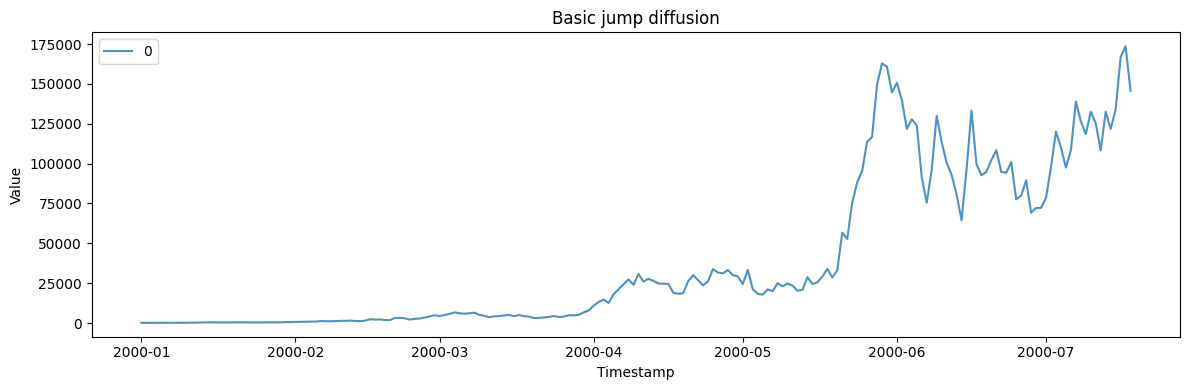

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in basic_df["unique_id"].unique().to_list():
    series = basic_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Basic jump diffusion")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Frequent jumps (high lambda)

Increase the jump intensity to produce more frequent discontinuities.

In [ ]:
frequent_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "mu": 0.05,
    "sigma": 0.1,
    "lambda_jump": 1.0,
    "jump_mean": 0.0,
    "jump_std": 0.05,
    "initial_value": 100.0,
    "seed": 42,
}

frequent_gen = JumpDiffusionGenerator(engine="polars", **frequent_params)
frequent_df = frequent_gen.generate(n_series=1)

print(f"Generated {len(frequent_df)} observations with frequent jumps")
print(f"Statistics: Mean={frequent_df['y'].mean():.4f}, Std={frequent_df['y'].std():.4f}")
frequent_df.head(10)

Generated 200 observations with frequent jumps
Statistics: Mean=36601.3764, Std=62200.4044


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.0
"""0""",2000-01-02 00:00:00,90.922801
"""0""",2000-01-03 00:00:00,101.217826
"""0""",2000-01-04 00:00:00,113.461651
"""0""",2000-01-05 00:00:00,144.23748
"""0""",2000-01-06 00:00:00,142.016058
"""0""",2000-01-07 00:00:00,136.783393
"""0""",2000-01-08 00:00:00,174.353855
"""0""",2000-01-09 00:00:00,219.244362


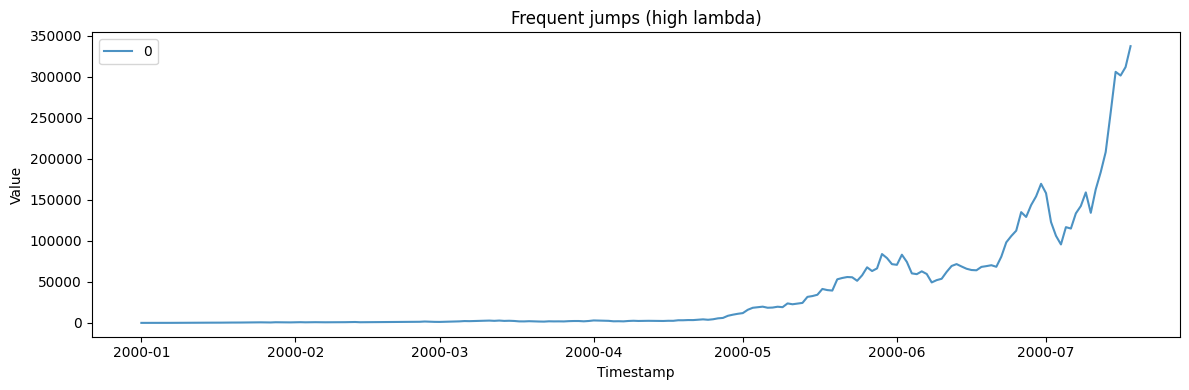

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in frequent_df["unique_id"].unique().to_list():
    series = frequent_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Frequent jumps (high lambda)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Large positive jumps (positive news shocks)

Set a positive jump mean to simulate upward shocks.

In [ ]:
positive_jump_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "mu": 0.05,
    "sigma": 0.15,
    "lambda_jump": 0.3,
    "jump_mean": 0.1,
    "jump_std": 0.05,
    "initial_value": 100.0,
    "seed": 42,
}

positive_jump_gen = JumpDiffusionGenerator(engine="polars", **positive_jump_params)
positive_jump_df = positive_jump_gen.generate(n_series=1)

print(f"Generated {len(positive_jump_df)} observations with positive jumps")
print(f"Statistics: Mean={positive_jump_df['y'].mean():.4f}, Std={positive_jump_df['y'].std():.4f}")
positive_jump_df.head(10)

Generated 200 observations with positive jumps
Statistics: Mean=1587269.2450, Std=3704480.0099


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.0
"""0""",2000-01-02 00:00:00,84.240947
"""0""",2000-01-03 00:00:00,108.034216
"""0""",2000-01-04 00:00:00,122.907561
"""0""",2000-01-05 00:00:00,131.034684
"""0""",2000-01-06 00:00:00,182.492003
"""0""",2000-01-07 00:00:00,198.60247
"""0""",2000-01-08 00:00:00,231.941512
"""0""",2000-01-09 00:00:00,235.939332


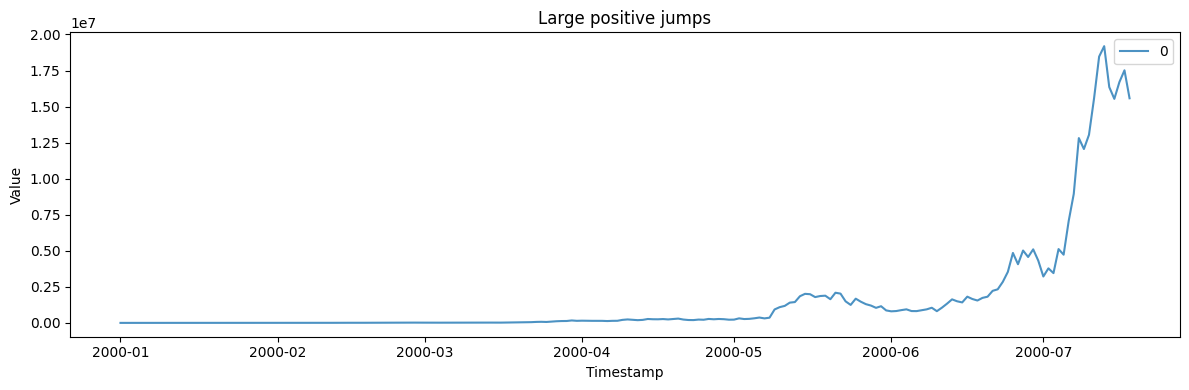

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in positive_jump_df["unique_id"].unique().to_list():
    series = positive_jump_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Large positive jumps")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Large negative jumps (market crashes)

A negative jump mean simulates crash-like events.

In [ ]:
negative_jump_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "mu": 0.05,
    "sigma": 0.15,
    "lambda_jump": 0.2,
    "jump_mean": -0.15,
    "jump_std": 0.08,
    "initial_value": 100.0,
    "seed": 42,
}

negative_jump_gen = JumpDiffusionGenerator(engine="polars", **negative_jump_params)
negative_jump_df = negative_jump_gen.generate(n_series=1)

print(f"Generated {len(negative_jump_df)} observations with crash-like jumps")
print(f"Statistics: Mean={negative_jump_df['y'].mean():.4f}, Std={negative_jump_df['y'].std():.4f}")
negative_jump_df.head(10)

Generated 200 observations with crash-like jumps
Statistics: Mean=986.9243, Std=778.0857


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.0
"""0""",2000-01-02 00:00:00,84.240947
"""0""",2000-01-03 00:00:00,82.475649
"""0""",2000-01-04 00:00:00,93.830282
"""0""",2000-01-05 00:00:00,100.034703
"""0""",2000-01-06 00:00:00,139.31833
"""0""",2000-01-07 00:00:00,113.001821
"""0""",2000-01-08 00:00:00,109.473303
"""0""",2000-01-09 00:00:00,111.360221


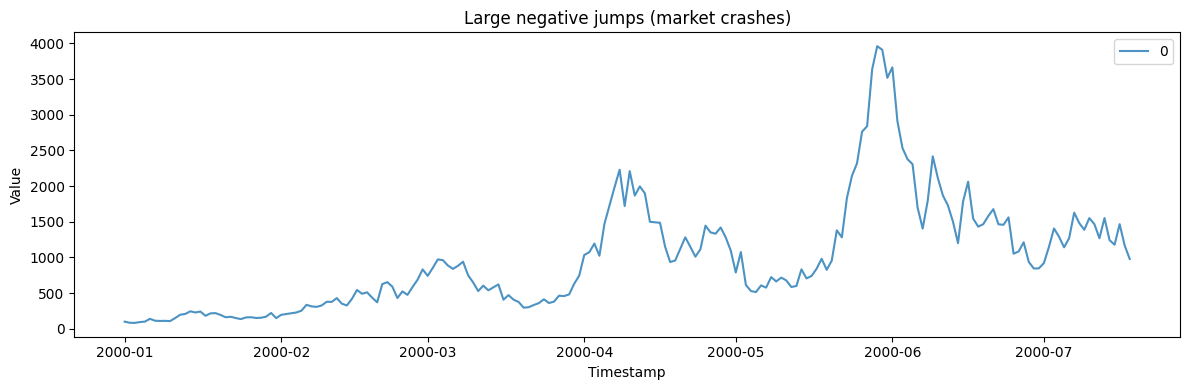

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in negative_jump_df["unique_id"].unique().to_list():
    series = negative_jump_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Large negative jumps (market crashes)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. High volatility jumps (uncertain jump sizes)

High jump_std produces widely varying jump magnitudes.

In [ ]:
high_vol_jump_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "mu": 0.05,
    "sigma": 0.15,
    "lambda_jump": 0.3,
    "jump_mean": 0.0,
    "jump_std": 0.2,
    "initial_value": 100.0,
    "seed": 42,
}

high_vol_jump_gen = JumpDiffusionGenerator(engine="polars", **high_vol_jump_params)
high_vol_jump_df = high_vol_jump_gen.generate(n_series=1)

print(f"Generated {len(high_vol_jump_df)} observations with high jump volatility")
print(f"Statistics: Mean={high_vol_jump_df['y'].mean():.4f}, Std={high_vol_jump_df['y'].std():.4f}")
high_vol_jump_df.head(10)

Generated 200 observations with high jump volatility
Statistics: Mean=29758.1542, Std=38723.7798


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.0
"""0""",2000-01-02 00:00:00,84.240947
"""0""",2000-01-03 00:00:00,88.475307
"""0""",2000-01-04 00:00:00,100.655928
"""0""",2000-01-05 00:00:00,107.311687
"""0""",2000-01-06 00:00:00,149.452985
"""0""",2000-01-07 00:00:00,118.131558
"""0""",2000-01-08 00:00:00,171.136693
"""0""",2000-01-09 00:00:00,174.086461


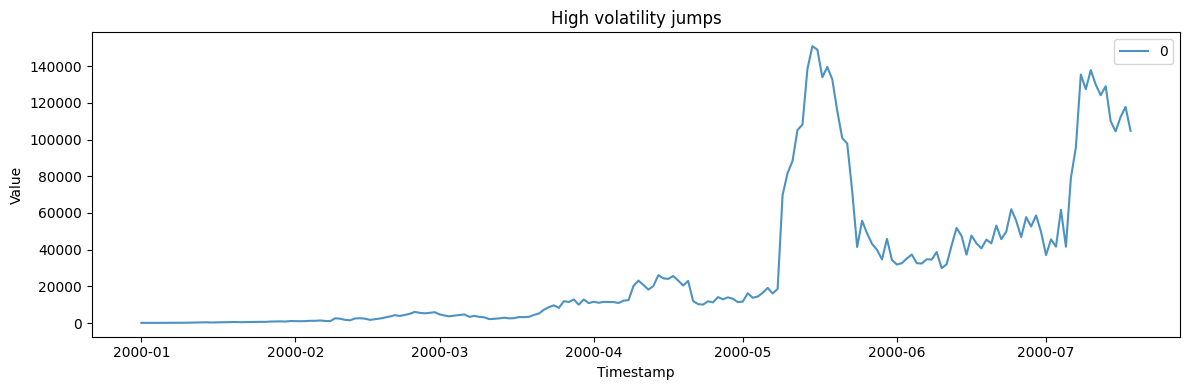

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in high_vol_jump_df["unique_id"].unique().to_list():
    series = high_vol_jump_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("High volatility jumps")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Multiple jump diffusion series

Generate multiple independent jump diffusion paths.

In [ ]:
multi_params = {
    "min_length": 150,
    "max_length": 150,
    "freq": "D",
    "mu": 0.05,
    "sigma": 0.15,
    "lambda_jump": 0.2,
    "jump_mean": 0.0,
    "jump_std": 0.1,
    "initial_value": 100.0,
    "seed": 42,
}

multi_gen = JumpDiffusionGenerator(engine="polars", **multi_params)
multi_df = multi_gen.generate(n_series=3)

print(f"Generated 3 series with {len(multi_df)} total observations")
print(f"Overall Statistics: Mean={multi_df['y'].mean():.4f}, Std={multi_df['y'].std():.4f}")
multi_df.filter(pl.col("unique_id") == "0").head(10)

Generated 3 series with 450 total observations
Overall Statistics: Mean=6662.1054, Std=16489.8470


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.0
"""0""",2000-01-02 00:00:00,84.240947
"""0""",2000-01-03 00:00:00,94.557346
"""0""",2000-01-04 00:00:00,107.575297
"""0""",2000-01-05 00:00:00,114.688591
"""0""",2000-01-06 00:00:00,159.7268
"""0""",2000-01-07 00:00:00,146.174789
"""0""",2000-01-08 00:00:00,171.596255
"""0""",2000-01-09 00:00:00,174.553944


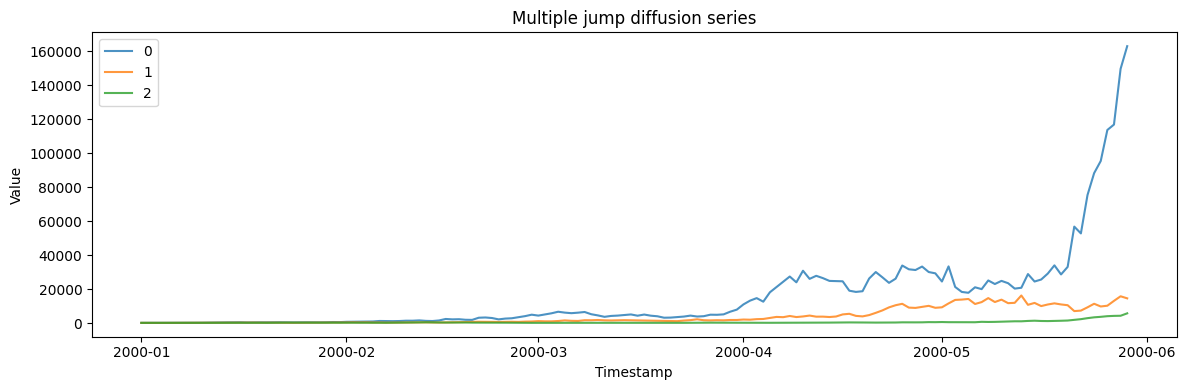

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Multiple jump diffusion series")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Geometric Brownian motion](geometric_brownian_motion) — the jump-free diffusion.
- [Hawkes process](hawkes_process) — when the jumps cluster and self-excite.

Jump intensity and size parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::